In [28]:
import requests

import torch
from PIL import Image
from transformers import AutoProcessor, AutoModelForCausalLM 

device = "mps"
torch_dtype = torch.float32

florence_model = AutoModelForCausalLM.from_pretrained("microsoft/Florence-2-large", torch_dtype=torch_dtype, trust_remote_code=True).to(device)
processor = AutoProcessor.from_pretrained("microsoft/Florence-2-large", trust_remote_code=True)

Error during conversion: ChunkedEncodingError(ProtocolError('Response ended prematurely'))


In [29]:
image = Image.open("/Users/theo.moreau/Documents/futur/datasets/mvtec_anomaly_detection/screw/test/scratch_head/005.png").convert("RGB")

def run_example(task_prompt, text_input=None):
    if text_input is None:
        prompt = task_prompt
    else:
        prompt = task_prompt + text_input
    inputs = processor(text=prompt, images=image, return_tensors="pt").to(device, torch_dtype)
    generated_ids = florence_model.generate(
      input_ids=inputs["input_ids"],
      pixel_values=inputs["pixel_values"],
      max_new_tokens=1024,
      num_beams=3
    )
    generated_text = processor.batch_decode(generated_ids, skip_special_tokens=False)[0]

    parsed_answer = processor.post_process_generation(generated_text, task=task_prompt, image_size=(image.width, image.height))

    print(parsed_answer)

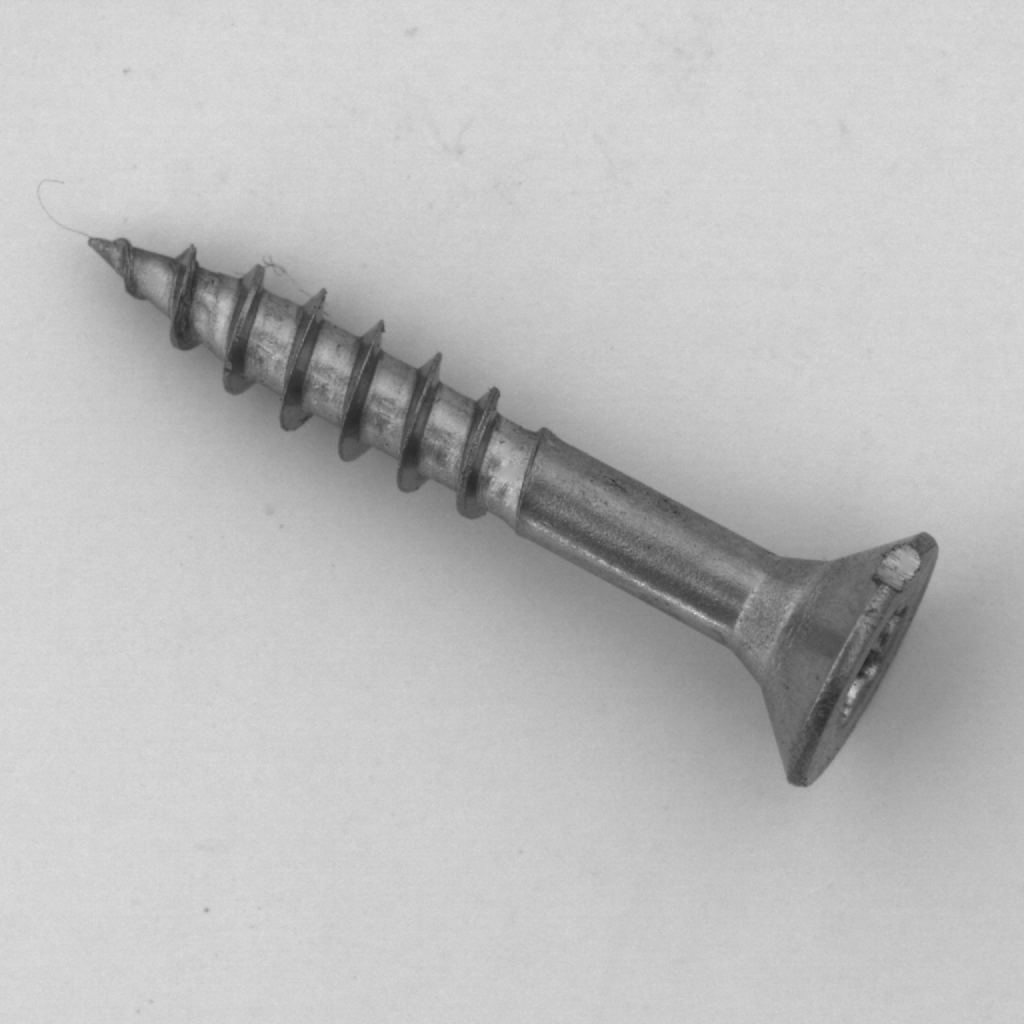

In [30]:
image

Execution time: 57.50 seconds

Processing 002.png:
{'<CAPTION_TO_PHRASE_GROUNDING>': {'bboxes': [[78.33600616455078, 246.2720184326172, 947.7120361328125, 777.72802734375]], 'labels': ['a screw']}}


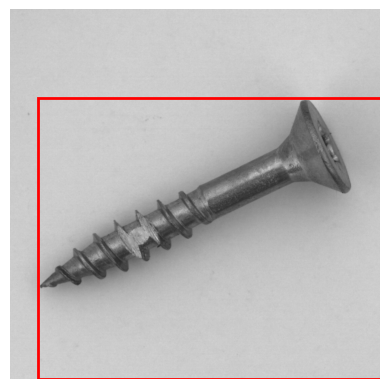

Execution time: 4.96 seconds

Processing 016.png:
{'<CAPTION_TO_PHRASE_GROUNDING>': {'bboxes': [[325.1200256347656, 54.78400421142578, 702.9760131835938, 969.216064453125]], 'labels': ['a screw']}}


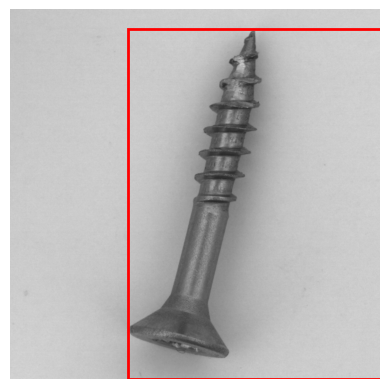

Execution time: 4.67 seconds

Processing 017.png:
{'<CAPTION_TO_PHRASE_GROUNDING>': {'bboxes': [[54.78400421142578, 336.3840026855469, 972.2880249023438, 680.4480590820312]], 'labels': ['a screw']}}


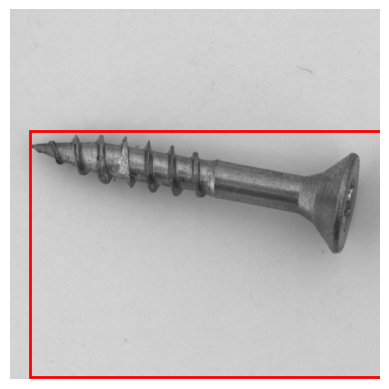

Execution time: 4.80 seconds

Processing 003.png:
{'<CAPTION_TO_PHRASE_GROUNDING>': {'bboxes': [[229.8880157470703, 83.45600128173828, 792.0640258789062, 937.4720458984375]], 'labels': ['a screw']}}


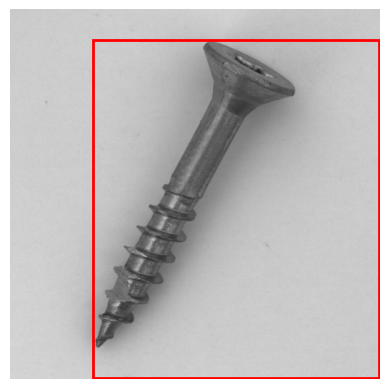

Execution time: 2.55 seconds

Processing 015.png:
{'<CAPTION_TO_PHRASE_GROUNDING>': {'bboxes': [[230.91201782226562, 78.33600616455078, 787.968017578125, 941.5680541992188]], 'labels': ['a screw']}}


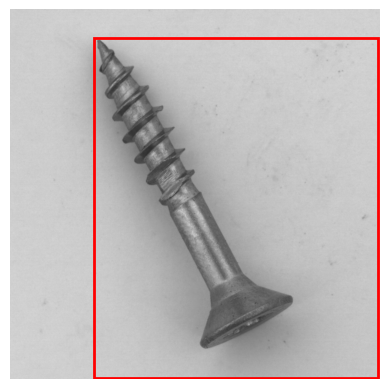

Execution time: 2.41 seconds

Processing 001.png:
{'<CAPTION_TO_PHRASE_GROUNDING>': {'bboxes': [[311.8080139160156, 55.80800247192383, 714.2400512695312, 968.1920166015625]], 'labels': ['a screw']}}


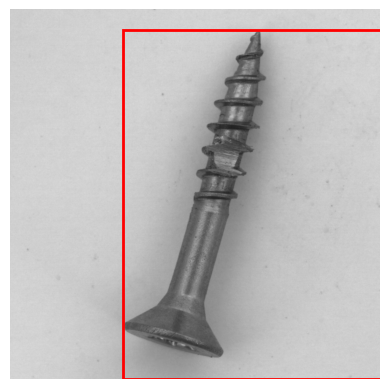

Execution time: 6.45 seconds

Processing 000.png:
{'<CAPTION_TO_PHRASE_GROUNDING>': {'bboxes': [[81.40800476074219, 223.74400329589844, 942.592041015625, 792.0640258789062]], 'labels': ['a screw']}}


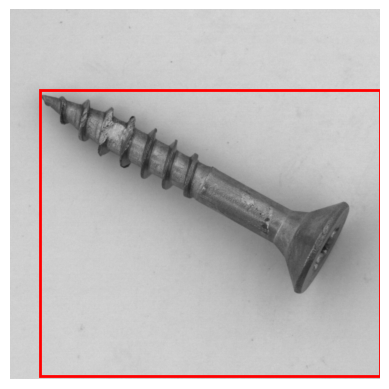

Execution time: 6.05 seconds

Processing 014.png:
{'<CAPTION_TO_PHRASE_GROUNDING>': {'bboxes': [[105.9840087890625, 186.8800048828125, 921.0880737304688, 839.1680297851562]], 'labels': ['a screw']}}


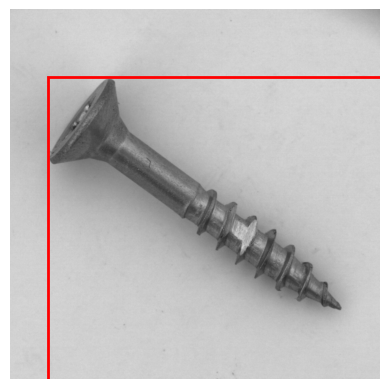

Execution time: 7.17 seconds

Processing 010.png:
{'<CAPTION_TO_PHRASE_GROUNDING>': {'bboxes': [[97.79200744628906, 197.12001037597656, 927.2320556640625, 820.7360229492188]], 'labels': ['a screw']}}


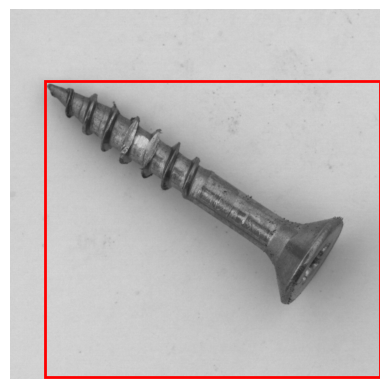

Execution time: 5.83 seconds

Processing 004.png:
{'<CAPTION_TO_PHRASE_GROUNDING>': {'bboxes': [[58.880001068115234, 324.09600830078125, 967.1680297851562, 702.9760131835938]], 'labels': ['a screw']}}


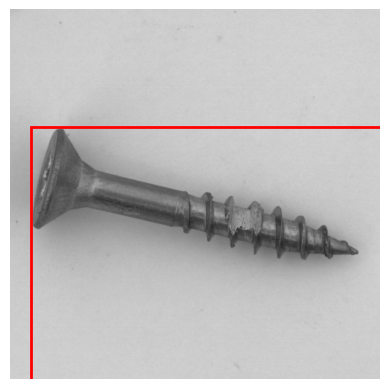

Execution time: 5.83 seconds

Processing 005.png:
{'<CAPTION_TO_PHRASE_GROUNDING>': {'bboxes': [[342.52801513671875, 52.73600387573242, 689.6640625, 967.1680297851562]], 'labels': ['a screw']}}


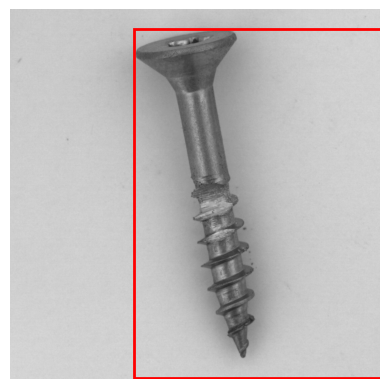

Execution time: 3.77 seconds

Processing 011.png:
{'<CAPTION_TO_PHRASE_GROUNDING>': {'bboxes': [[74.24000549316406, 260.6080017089844, 950.7840576171875, 765.4400634765625]], 'labels': ['a screw']}}


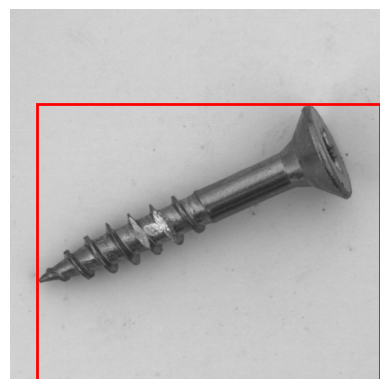

Execution time: 6.28 seconds

Processing 007.png:
{'<CAPTION_TO_PHRASE_GROUNDING>': {'bboxes': [[322.0480041503906, 53.76000213623047, 702.9760131835938, 966.14404296875]], 'labels': ['a screw']}}


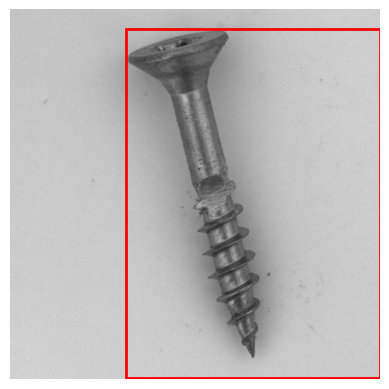

KeyboardInterrupt: 

In [41]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import time

def show_bboxes(image, bboxes):
    # Create figure and axes
    fig, ax = plt.subplots()
    
    # Display the image
    ax.imshow(image)
    
    # Add bounding boxes
    for bbox in bboxes:
        # Create a Rectangle patch
        x, y, w, h = bbox
        rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='r', facecolor='none')
        
        # Add the patch to the Axes
        ax.add_patch(rect)
    
    plt.axis('off')
    plt.show()

# Get bounding boxes for 60 images
import glob
import os

# Get list of test images
test_image_dir = "/Users/theo.moreau/Documents/futur/datasets/mvtec_anomaly_detection/screw/test"
image_paths = []
for defect_type in os.listdir(test_image_dir):
    defect_dir = os.path.join(test_image_dir, defect_type)
    if os.path.isdir(defect_dir):
        image_paths.extend(glob.glob(os.path.join(defect_dir, "*.png")))

# Process first 60 images
task_prompt = "<CAPTION_TO_PHRASE_GROUNDING>"
text_input = "a screw"

for image_path in image_paths[:60]:
    # Load and process image
    image = Image.open(image_path).convert("RGB")
    start_time = time.time()
    inputs = processor(text=task_prompt + text_input, images=image, return_tensors="pt").to(device, torch_dtype)
    
    generated_ids = florence_model.generate(
        input_ids=inputs["input_ids"],
        pixel_values=inputs["pixel_values"], 
        max_new_tokens=1024,
        num_beams=3
    )
    generated_text = processor.batch_decode(generated_ids, skip_special_tokens=False)[0]
    parsed_answer = processor.post_process_generation(generated_text, task=task_prompt, image_size=(image.width, image.height))
    end_time = time.time()
    print(f"Execution time: {end_time - start_time:.2f} seconds")

    print(f"\nProcessing {os.path.basename(image_path)}:")
    print(parsed_answer)
    
    # Display image with bounding boxes
    show_bboxes(image, parsed_answer['<CAPTION_TO_PHRASE_GROUNDING>']["bboxes"])

In [37]:
from ultralytics import SAM
import matplotlib.pyplot as plt

model = SAM("mobile_sam.pt").to("mps")
results = model(image, bboxes=parsed_answer['<CAPTION_TO_PHRASE_GROUNDING>']["bboxes"], imgsz=480)


0: 480x480 1 0, 108.4ms
Speed: 2.6ms preprocess, 108.4ms inference, 2.5ms postprocess per image at shape (1, 3, 480, 480)


In [19]:
results[0].masks.data[0]

tensor([[False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False],
        ...,
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False]], device='mps:0')

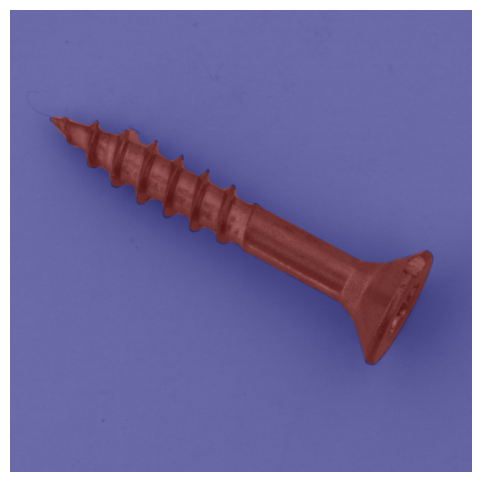

In [38]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Get the mask from results and resize to match image dimensions
mask = results[0].masks.data[0]
mask_resized = cv2.resize(mask.cpu().numpy().astype(np.uint8), (image.width, image.height))

# Create figure and axis
plt.figure(figsize=(8, 6))
ax = plt.gca()

# Display original image
ax.imshow(image)

# Overlay resized mask with transparency
ax.imshow(mask_resized, alpha=0.5, cmap='jet')

plt.axis('off')
plt.show()
